## PARTE 0 - SETUP

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier

## PARTE 1 - K-MEANS
### ATTIVITÀ 1.1 - CLUSTERING DI BASE

Centroidi:
 [[ 4.68904627  1.94358124]
 [-8.74425361  7.40268042]
 [-6.95242982 -6.89471836]
 [-2.5650083   9.06117548]]
Inertia: 341.6005236015555


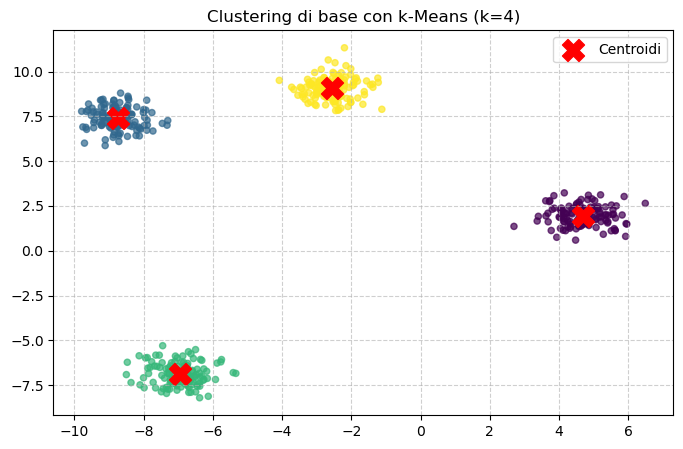

In [5]:
# generiamo il dataset sintetico
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)

# inizializziamo e addestriamo il modello 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

# stampiamo i centroidi e l'inerzia
print("Centroidi:\n", kmeans.cluster_centers_)
print("Inertia:", kmeans.inertia_)

# visualizziamo i punti colorati per cluster e sovrapponiamo i centroidi (1)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=250, c='red', marker='X', label='Centroidi')

plt.title("Clustering di base con k-Means (k=4)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2. L'inerzia rappresenta la somma delle distanze al quadrato tra le singole istanze (i punti del dataset) e i centroidi dei cluster a cui sono state assegnate. Si tratta di una metrica che misura la compattezza dei cluster: un valore più basso indica che i punti sono, in media, molto vicini al centro del proprio cluster. Durante l'addestramento, l'algoritmo k-Means cerca proprio di minimizzare l'inerzia iterazione dopo iterazione.
3. Sì, i cluster trovati corrispondono perfettamente alla struttura visiva del dataset. Questo accade perché abbiamo generato un dataset sintetico composto da 4 "nuvole" (blob) distinte utilizzando make_blobs con il parametro centers=4 , e abbiamo poi addestrato l'algoritmo k-Means sapendo già che il numero di cluster da cercare era $k=4$. I centroidi si sono posizionati correttamente al centro di ciascun gruppo visivo.

### ATTIVITÀ 1.2 - NUMERO DI CLUSTER

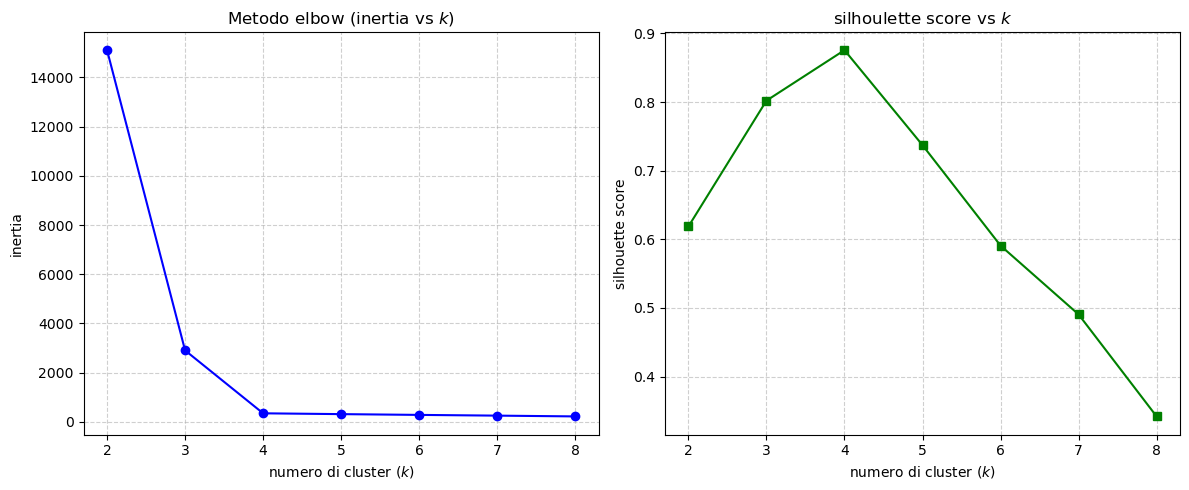

In [14]:
k_values = range (2,9)
inertias = []
sil_scores = []

# ciclo per testare i diversi valori di k
for k in k_values:
    model = KMeans (n_clusters=k, random_state=42, n_init=10)
    labels= model.fit_predict(X)

    # salviamo l'inerzia e la silhouette score
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# grafico elbow (1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, inertias, marker='o', linestyle='-', color='b')
plt.title("Metodo elbow (inertia vs $k$)")
plt.xlabel("numero di cluster ($k$)")
plt.ylabel("inertia")
plt.grid(True, linestyle='--', alpha=0.6)

# grafico con la silhouette score (2)
plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='s', linestyle='-', color='g')
plt.title("silhoulette score vs $k$")
plt.xlabel("numero di cluster ($k$)")
plt.ylabel("silhouette score")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


3. Il valore più ragionevole è $k=4$. Osservando il grafico a gomito (Elbow method), possiamo notare che l'inerzia diminuisce rapidamente fino a $k=4$, per poi iniziare a scendere in modo molto più lento (formando, appunto, un "gomito"). La conferma definitiva ci viene dal grafico del Silhouette Score: il valore del punteggio raggiunge il suo picco massimo proprio in corrispondenza di $k=4$, indicando che a questo valore i cluster sono sia ben compatti al loro interno sia ben separati tra loro.
4. L'inerzia misura la somma delle distanze al quadrato tra ogni punto e il centroide del cluster a cui appartiene. Aumentando il numero di cluster ($k$), il numero di centroidi sparsi nello spazio aumenta. Di conseguenza, ogni punto avrà statisticamente un centroide più vicino a sé, rendendo le distanze (e quindi l'inerzia) sempre più piccole. Nel caso limite in cui $k$ fosse uguale al numero totale di punti nel dataset, ogni punto sarebbe un cluster a sé stante, la distanza dal proprio centroide sarebbe zero, e l'inerzia totale sarebbe esattamente zero. Per questo motivo, l'inerzia da sola non è un indicatore sufficiente per scegliere $k$.

### ATTIVITÀ 1.3 - DECISION BOUNDARIES

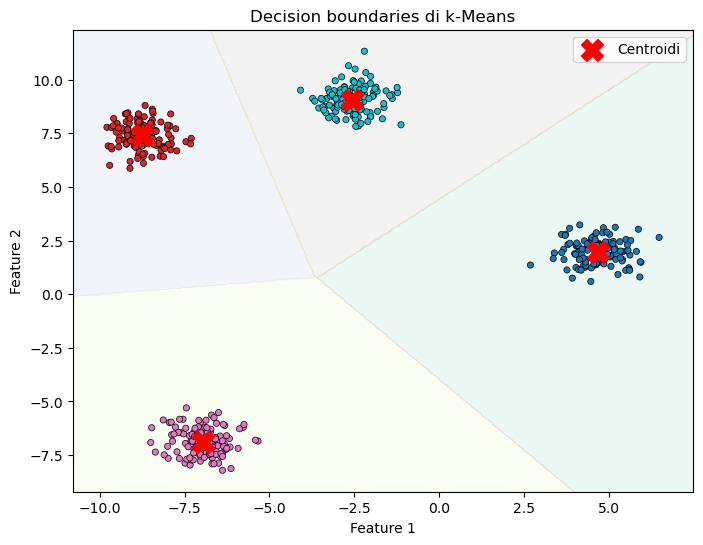

In [15]:
# creiamo una griglia di punti che copra l'area del nostro dataset
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# meshgrid, crea la griglia 2D
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# facciamo predire al modello a quale cluster appartiene ogni punto della griglia
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# disegniamo i confini decisionali
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="Pastel2")

# sovrapponiamo i punti reali del dataset
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20, cmap="tab10", edgecolors='k', linewidth=0.5)

# aggiungiamo i centroidi
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250, c="red", marker="X", label="Centroidi"
)

plt.legend()
plt.title("Decision boundaries di k-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

1. Le regioni colorate rappresentano le aree dello spazio delle feature associate a ciascun cluster. Qualsiasi nuovo punto (o nuova osservazione) cadesse all'interno di una determinata regione colorata, verrebbe classificato dall'algoritmo k-Means come appartenente al cluster di quel colore.
2. Le frontiere decisionali (decision boundaries) del k-Means definiscono esattamente una tassellazione di Voronoi. In un diagramma di Voronoi, lo spazio viene diviso in regioni in base alla distanza da un insieme di punti fissi (nel nostro caso, i centroidi). Ogni regione contiene tutti i punti dello spazio che sono più vicini al proprio centroide rispetto a qualsiasi altro centroide.
3. Il k-Means assegna le istanze basandosi esclusivamente sulla distanza euclidea dal centroide. Questo fa sì che le frontiere decisionali siano sempre linee rette (iperpiani) poste esattamente a metà strada tra due centroidi. Se i cluster hanno forme allungate (ellissoidi), densità molto diverse o forme irregolari (come delle lune o degli anelli), il k-Means sbaglierà a segmentarli perché l'algoritmo non è in grado di curvare i confini per seguire la forma reale dei dati.

- Funziona bene con dataset di grandi dimensioni (poiché è molto veloce e scalabile) e in situazioni in cui i cluster sono ben separati, hanno dimensioni (varianze) simili tra loro, hanno una forma approssimativamente sferica e, non per ultimo, quando si ha un'idea chiara del numero di cluster $k$ da cercare.
- Fa l'ipotesi implicita che i cluster siano convessi, isotropici (ovvero sferici, che si espandono ugualmente in tutte le direzioni) e che abbiano all'incirca tutti lo stesso diametro/volume.
- È sensibile agli outlier perché il centroide di un cluster viene calcolato matematicamente come la media aritmetica della posizione di tutti i punti assegnati a quel cluster. Un punto anomalo (outlier) molto distante dal gruppo principale influenzerà pesantemente la media, "trascinando" il centroide verso di sé e distorcendo di conseguenza le decision boundaries.

## PARTE 2 - DBSCAN
### ATTIVITÀ 2.1 - DATASET NON LINEARE

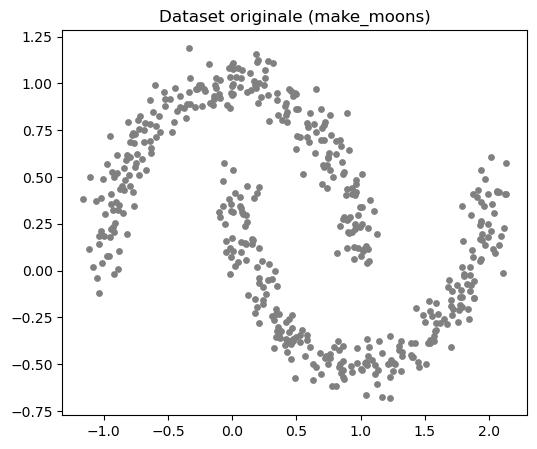




Etichette trovate: [0 1]
Numero cluster (senza rumore): 2
Numero punti di rumore: 0 





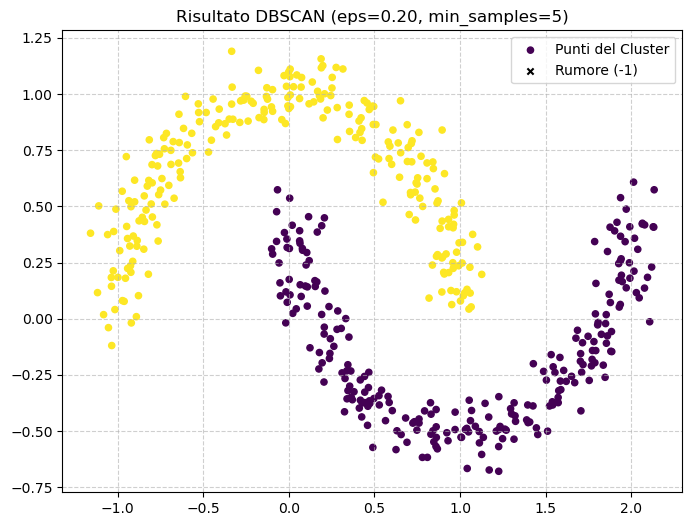

In [17]:
# generiamo dataset a due lune
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=42)

# visualizziamo il dataset originale
plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=15, color='gray')
plt.title("Dataset originale (make_moons)")
plt.show()

# applichiamo DBSCAN
dbscan = DBSCAN(eps=0.20, min_samples=5)
labels = dbscan.fit_predict(X_moons)

print("\n\n\nEtichette trovate:", np.unique(labels))
print("Numero cluster (senza rumore):", len(set(labels)) - (1 if -1 in labels else 0))
print("Numero punti di rumore:", np.sum(labels == -1), "\n\n\n")

# visualizziamo i cluster trovati, colorando in nero i punti con etichetta -1 (1)
plt.figure(figsize=(8, 6))

# creiamo due maschere booleane: una per i punti clusterizzati e una per il rumore
mask_noise = (labels == -1)
mask_core_border = (labels != -1)

# disegniamo i punti clusterizzati
plt.scatter(X_moons[mask_core_border, 0], X_moons[mask_core_border, 1], 
            c=labels[mask_core_border], s=20, cmap="viridis", label="Punti del Cluster")

# disegniamo i punti di rumore in nero
plt.scatter(X_moons[mask_noise, 0], X_moons[mask_noise, 1], 
            c="black", s=20, marker="x", label="Rumore (-1)")

plt.title("Risultato DBSCAN (eps=0.20, min_samples=5)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2.
   - **eps** ($\epsilon$): rappresenta la distanza massima (il raggio) per considerareun'istanza come parte dell'intorno (o "vicinato") di un'altra istanza.
   - **min_samples**: è il numero minimo di istanze che un punto deve avere nel proprio $\epsilon$-intorno (incluso se stesso) affinché quel punto possa essere considerato un punto "centrale" (core instance) all'interno di una regione densa.
3. - **core points**: sono punti che si trovano in regioni dense nello spazio, ovvero hanno almeno **min_samples** punti all'interno del proprio $\epsilon$-intorno
   - **border points**: non hanno abbastanza punti nel loro intorno per essere dei core points, ma ricadono comunque all'interno dell'$\epsilon$-intorno di un core point vicino, per cui appartengono allo stesso cluster
   - **noise points**: sono punti isolati che non sono core points e non si trovano alll'interno di nessun core points. A questi punti DBSCAN assegna l'etichetta `-1`

### ATTIVITÀ 2.2 - SENSIBILITÀ AGLI IPERPARAMETRI

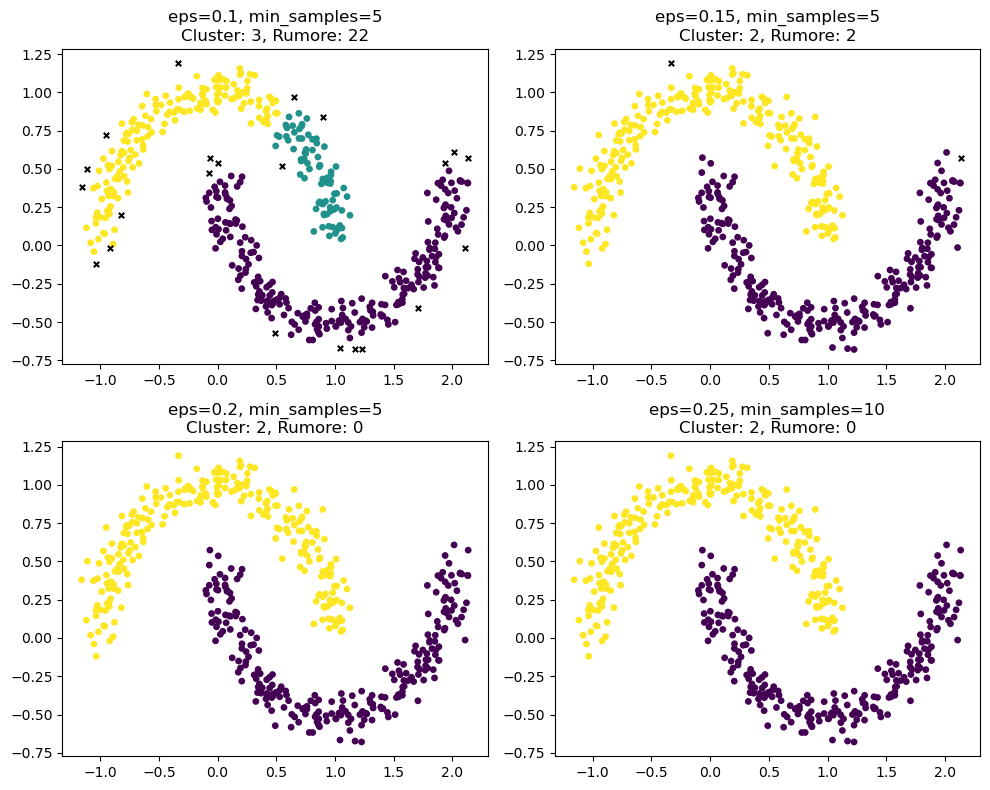

,eps,min_samples,Numero Cluster,Punti Rumore
0,0.10,5,3,22
1,0.15,5,2,2
2,0.20,5,2,0
3,0.25,10,2,0


In [18]:
# configurazioni
configs = [
    (0.10, 5),
    (0.15, 5),
    (0.20, 5),
    (0.25, 10)
]

# lista per memorizzare i risultati per la tabella
results = []

plt.figure(figsize=(10, 8))

for i, (eps, min_samples) in enumerate(configs):
    # inizializziamo ed addestriamo DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_moons)
    
    # calcolo del numero di cluster e di punti rumore
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    # salviamo i dati per la tabella
    results.append({
        "eps": eps,
        "min_samples": min_samples,
        "Numero Cluster": n_clusters,
        "Punti Rumore": n_noise
    })
    
    # creiamo un subplot per ogni configurazione
    plt.subplot(2, 2, i+1)
    mask_noise = (labels == -1)
    mask_core_border = (labels != -1)
    
    plt.scatter(X_moons[mask_core_border, 0], X_moons[mask_core_border, 1], 
                c=labels[mask_core_border], s=15, cmap="viridis")
    plt.scatter(X_moons[mask_noise, 0], X_moons[mask_noise, 1], 
                c="black", s=15, marker="x")
    
    plt.title(f"eps={eps}, min_samples={min_samples}\nCluster: {n_clusters}, Rumore: {n_noise}")

plt.tight_layout()
plt.show()

# creare una tabella con: eps, min_samples, numero di cluster, punti rumore (1)
df_results = pd.DataFrame(results)
display(df_results) # display mostra una bella tabella formattata (jupyter)

2. All'aumentare di eps (mantenendo fisso min_samples), il "raggio" di ricerca intorno a ogni punto si allarga. Di conseguenza, è più facile per i punti trovare vicini e diventare core points, e per i punti isolati essere inglobati nel bordo di un cluster. Come risultato, il numero di punti classificati come rumore diminuisce drasticamente. Se eps diventa troppo grande, cluster che dovrebbero essere distinti rischiano di fondersi in un unico enorme ammasso
3. All'aumentare di min_samples (mantenendo fisso eps), la condizione per definire una regione "densa" diventa più severa: serve un numero maggiore di punti vicini affinché un'istanza diventi un core point. Di conseguenza, le regioni a densità più bassa smettono di essere considerate cluster validi, il numero di punti etichettati come rumore aumenta e i cluster possono finire per frammentarsi in pezzi più piccoli.
4. La configurazione migliore per questo specifico dataset è eps=0.20 e min_samples=5. Come si evince dal grafico, questa combinazione riesce a separare perfettamente la struttura delle due lune, isolando come rumore solo quei pochi punti che effettivamente deviano troppo dalla forma principale (gli outlier più estremi), senza frammentare le lune stesse.

### ATTIVITÀ 2.3 - FRONTIERE DECISIONALI APPROSSIMATE

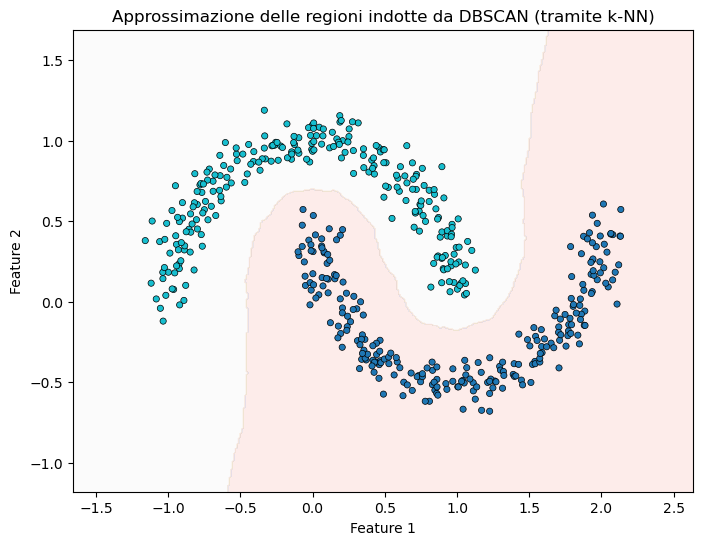

In [19]:
# riaddestro DBSCAN con i parametri ottimali
dbscan_opt = DBSCAN(eps=0.20, min_samples=5)
labels_opt = dbscan_opt.fit_predict(X_moons)

# creo una maschera per escludere il rumore (etichetta -1)
mask = labels_opt != -1
X_core = X_moons[mask]
y_core = labels_opt[mask]

# addestriamo il classificatore k-NN sui punti non rumorosi
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_core, y_core)

# Creiamo la griglia per le frontiere
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# facciamo predire al k-NN le regioni
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# plottiamo il grafico
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="Pastel1")

# disegniamo i punti, colorati secondo le etichette originali di DBSCAN
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_opt, s=20, cmap="tab10", edgecolors='k', linewidth=0.5)

plt.title("Approssimazione delle regioni indotte da DBSCAN (tramite k-NN)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

1. DBSCAN lavora misurando la densità locale dei dati e definendo i cluster come regioni continue ad alta densità. Non calcola né memorizza equazioni matematiche per dividere lo spazio vuoto. Per colorare il grafico stiamo usando un altro algoritmo (il k-NN) che si basa semplicemente sulla vicinanza (distanza euclidea) ai punti che DBSCAN ha precedentemente etichettato. Il confine curvo che vediamo è quindi opera del k-NN, non di DBSCAN.
2. A differenza del k-Means, le cui frontiere sono sempre iperpiani netti e rettilinei (poligoni di Voronoi) , questa frontiera approssimata segue in modo flessibile la distribuzione "organica" e non lineare dei punti. La linea di separazione serpeggia esattamente in mezzo alla valle a bassa densità che separa le due lune.
3. Il vantaggio assoluto è che DBSCAN è in grado di identificare cluster di qualsiasi forma arbitraria (come le lune, cerchi concentrici, forme a "S"), proprio perché non cerca forme geometriche chiuse (come gli ellissoidi/sfere del k-Means), ma segue semplicemente i collegamenti tra punti densamente raggruppati.

- I vantaggi principali sono due: primo, non richiede di specificare a priori il numero di cluster da cercare $k$; secondo, è estremamente robusto agli outlier, poiché li riconosce attivamente e li etichetta come rumore (anziché esserne deviato).
- DBSCAN va in difficoltà quando i cluster all'interno del dataset presentano densità molto diverse tra loro. Se min_samples o eps sono calibrati per un cluster molto denso, potrebbero ignorare un cluster più "rarefatto" considerandolo rumore; viceversa, calibrandoli sul cluster rarefatto, si potrebbero fondere per errore cluster vicini. Fallisce anche se non c'è una chiara "valle" a bassa densità a separare i cluster.
- Il parametro eps è una distanza geometrica assoluta. Se misuriamo due feature ad esempio in "metri", una distanza tra punti potrebbe essere 0.1; se cambiamo la scala in "millimetri", la distanza diventerà 100. Se non applichiamo uno scaling standardizzato delle feature prima di addestrare il modello, dovremo indovinare un valore di eps completamente diverso a seconda dell'unità di misura utilizzata.

## PARTE 3 - ISOLATION FOREST
### ATTIVITÀ 3.1 - GENERAZIONE DATI CON OUTLIER

Valori possibili: [-1  1]
Anomalie rilevate: 57


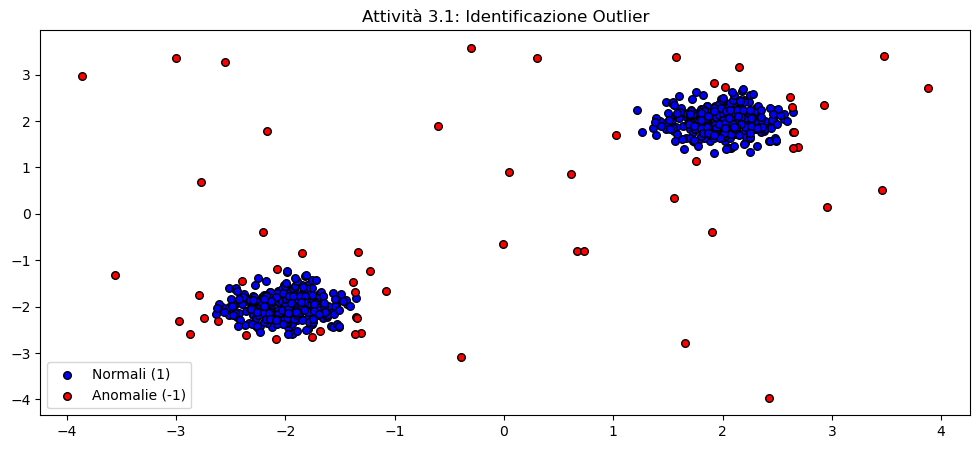

In [24]:
rng = np.random.RandomState(42)

# generiamo gli inlier (punti normali, 2 blob)
X_inliers = 0.3 * rng.randn(300, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
# generiamo gli outlier (punti sparsi casualmente)
X_outliers = rng.uniform(low=-4, high=4, size=(30, 2))
# uniamo tutto in un unico dataset
X_iforest = np.r_[X_inliers, X_outliers]

# applichiamo Isolation Forest
iso = IsolationForest(contamination=0.09, random_state=42)
y_pred_iso = iso.fit_predict(X_iforest)

print("Valori possibili:", np.unique(y_pred_iso))
print("Anomalie rilevate:", np.sum(y_pred_iso == -1))

# visualizziamo i punti normali e quelli anomali (1)
plt.figure(figsize=(12, 5))

plt.plot()

# punti  normali (1) in blu
plt.scatter(X_iforest[y_pred_iso == 1, 0], X_iforest[y_pred_iso == 1, 1], 
            c='blue', edgecolors='k', s=30, label='Normali (1)')

# punti anomali (-1) in rosso
plt.scatter(X_iforest[y_pred_iso == -1, 0], X_iforest[y_pred_iso == -1, 1], 
            c='red', edgecolors='k', s=30, label='Anomalie (-1)')
plt.title("Attività 3.1: Identificazione Outlier")
plt.legend()

2. Il parametro contamination indica la percentuale (o la proporzione) attesa di valori anomali all'interno del dataset. Impostandolo a 0.09 (9%), stiamo dicendo all'algoritmo di aggiustare la propria soglia decisionale in modo da etichettare come outlier (con valore -1) esattamente il 9% delle istanze, ovvero quelle con i punteggi di anomalia più estremi.
3. L'algoritmo costruisce una Random Forest in cui i singoli alberi decisionali vengono creati scegliendo ad ogni nodo una feature in modo casuale e una soglia di divisione (un taglio) anch'essa casuale. Lo spazio viene progressivamente tagliato a pezzi finché ogni singolo punto non rimane isolato nella sua "foglia" dell'albero. Gli outlier si trovano tipicamente in regioni molto più "vuote" e lontane dal nucleo centrale dei dati. A causa di questa lontananza, mediamente serviranno molti meno "tagli" casuali per separare un outlier dal resto del gruppo rispetto a quanti ne servano per isolare un punto normale immerso in un cluster denso. L'Isolation Forest calcola quanto "breve" è stato il percorso per isolare un punto: se è stato molto breve, il punto è altamente sospetto di essere un'anomalia.

### ATTIVITÀ 3.2 - DECISION FUNCTION E FRONTIERA

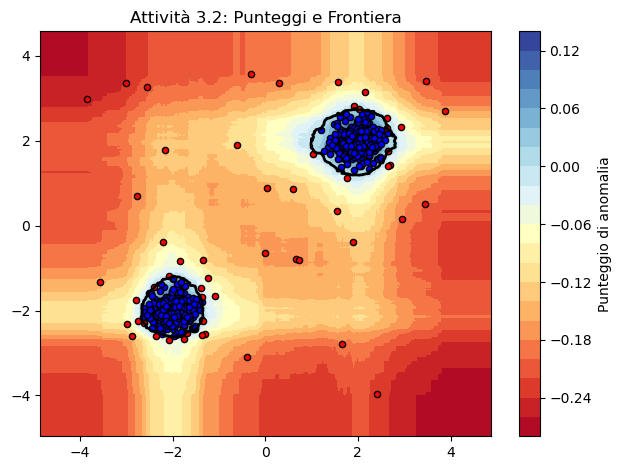

In [23]:
x_min, x_max = X_iforest[:, 0].min() - 1, X_iforest[:, 0].max() + 1
y_min, y_max = X_iforest[:, 1].min() - 1, X_iforest[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

# calcoliamo i punteggi (più è basso, più è anomalo)
scores = iso.decision_function(grid).reshape(xx.shape)

plt.plot()
# disegniamo la mappa dei punteggi
contour = plt.contourf(xx, yy, scores, levels=20, cmap="RdYlBu")
# plottiamo la frontiera esatta che divide normali da anomali (livello 0)
plt.contour(xx, yy, scores, levels=[0], linewidths=2, colors='black')

# sovrapponiamo i punti reali
plt.scatter(X_iforest[y_pred_iso == 1, 0], X_iforest[y_pred_iso == 1, 1], 
            c='blue', edgecolors='k', s=20)

plt.scatter(X_iforest[y_pred_iso == -1, 0], X_iforest[y_pred_iso == -1, 1], 
            c='red', edgecolors='k', s=20)

plt.title("Attività 3.2: Punteggi e Frontiera")
plt.colorbar(contour, label='Punteggio di anomalia')

plt.tight_layout()
plt.show()